In [3]:
#import all necessary libraries and packages for the analysis
from imports import *

# Reproducing the Miltiadous preprocessing pipeline 
We will be closely replicating (to the best of our ability) the paper's pipeline to remove artifacts in the EEG. 
It cannot be exact because we are using Python, while the paper worked in EEGLAB

1. Butterworth band-pass filter: 0.5 - 45 Hz
2. Re-reference to the average of A1 and A2
3. Run ICA
4. Remove ICA components labeled as eye or jaw artifacts

End goal of this notebook is to create a clean EEG version 

## 1. Butterworth band-pass filter: 0.5 - 45 Hz
<0.5 will help remove slow drift
\>45 will help remove muscle movements

In [4]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=45,
    method='iir',
    iir_params=dict(order=4,ftype='butter')
)

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

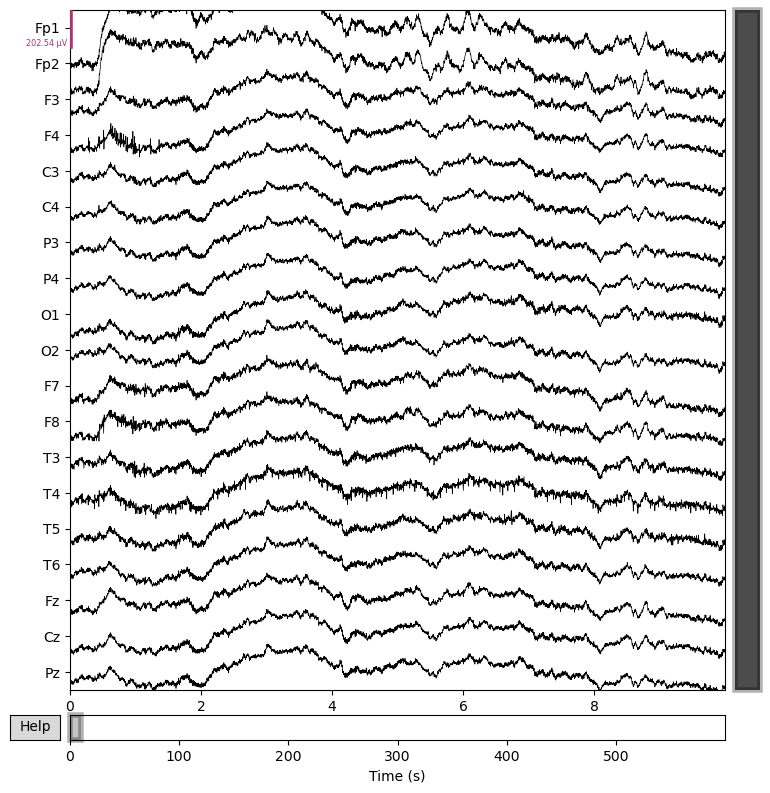

In [14]:
# visualize raw EEG
raw.plot(duration=10, scalings="auto");

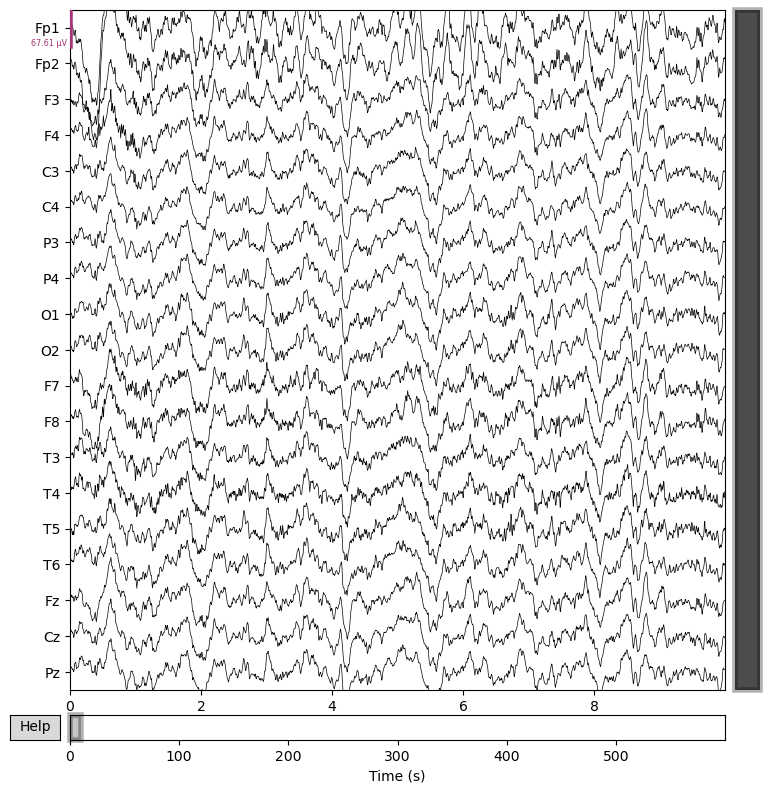

In [15]:
#visualize filtered EEG
raw_filtered.plot(duration=10, scalings="auto");

Upon observation comparing the two EEGs, unfiltered and filtered (butterworth band-pass filter), the filtered signal is slightly "cleaner" and smoother. 

Some reasons for this: 

- getting rid of high frequencies removed the small jagged spikes (making it look smoother and more defined)
- getting rid of low frequencies reduced some of the drifts(?) -not sure

However, it is not much of a difference

In [16]:
#Visualize diference by looking at the power spectrum (PSD)

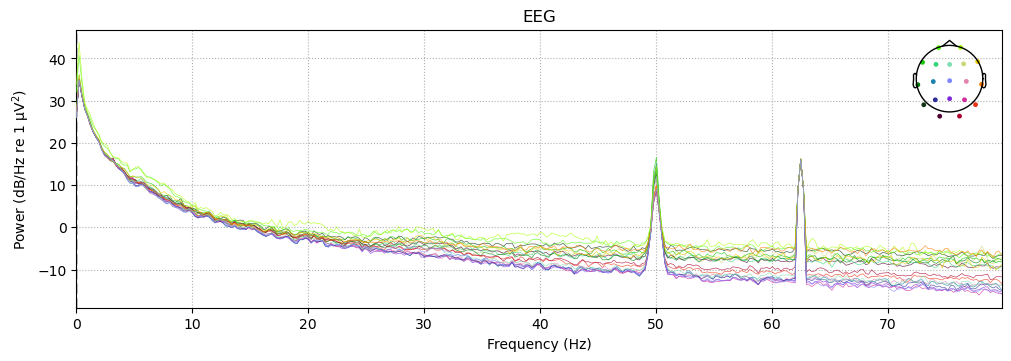

In [17]:
raw.compute_psd(fmax=80).plot()

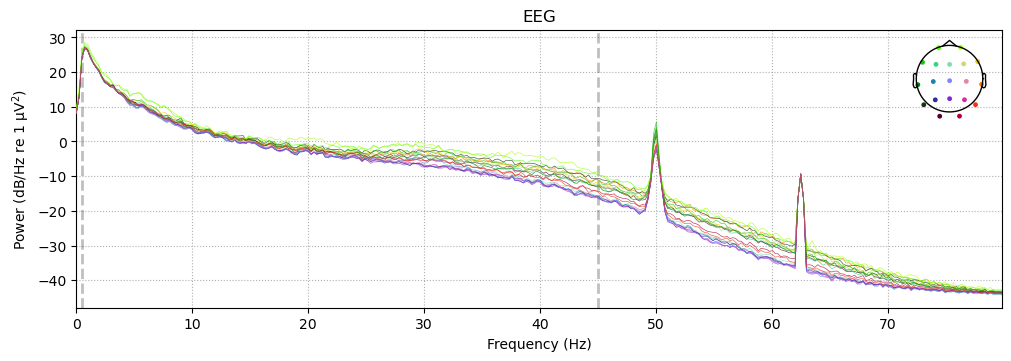

In [18]:
raw_filtered.compute_psd(fmax=80).plot()

Now comparing the power spectrum of the unfiltered vs. filtered, we can more visually see the effects of the butterworth bandpass filter. In the raw data, the power extends beyond 45 Hz. In the filtered, the power is cut off immediately t 45 Hz.

You can also notice a brief spike in the 50 Hz and 63 Hz range, this can be attributed to machine noise, electrical noise, etc. Since the bandpass filter already filters out >45 Hz, we do not have to worry about filtering this out with a Notch filter. So we will skip this filter.

## Re referencing 

Each channel is measured relative to a reference electrode, so if the reference electrode is noisy, all channels will inherit this noise. We will redefine this reference using an ***average*** reference

In [19]:
raw_ref = raw_filtered.copy()
raw_ref.set_eeg_reference('average')

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

## ICA (Independent Component Analysis) 
ICA (not mentioned in class) however it is the main artifact removal step in the paper.
- a method that separates mixed signals (brain activity + eye artifact + muscle artifact + noise) into independent sources

In this step, we are splitting 19 electrodes into 19 components, where each component will represent a source signal 
- Example: source1: eye blinks, source2: muscle activity

In [23]:
ica = ICA(
    n_components=18,
    random_state=97,
    max_iter="auto"
)

ica.fit(raw_ref)

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,27 iterations on raw data (299900 samples)
ICA components,18
Available PCA components,19
Channel types,eeg
ICA components marked for exclusion,—


Chose 18 components instead of 19, even though there are 19 available PCA components. This is because when I chose 19, there was a warning. The warning was because some channels have a very small variance, and so I reduced the number of components 

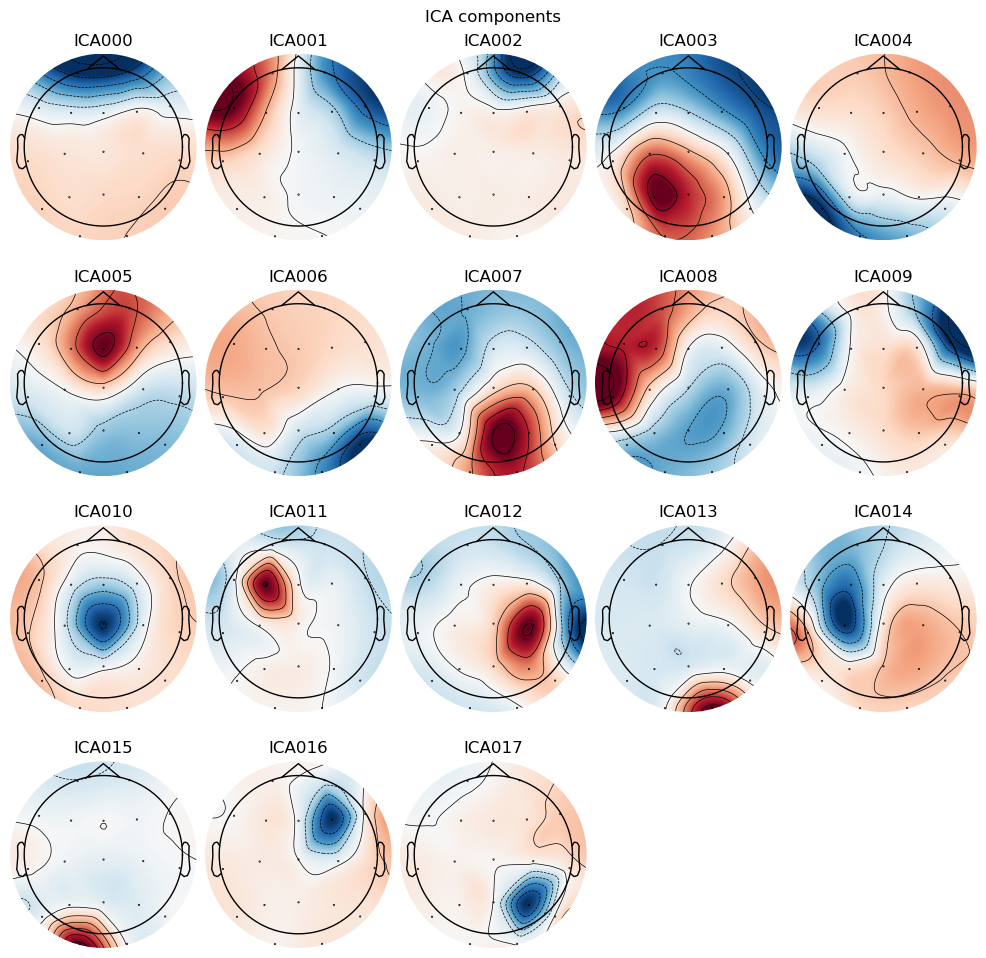

In [24]:
ica.plot_components();

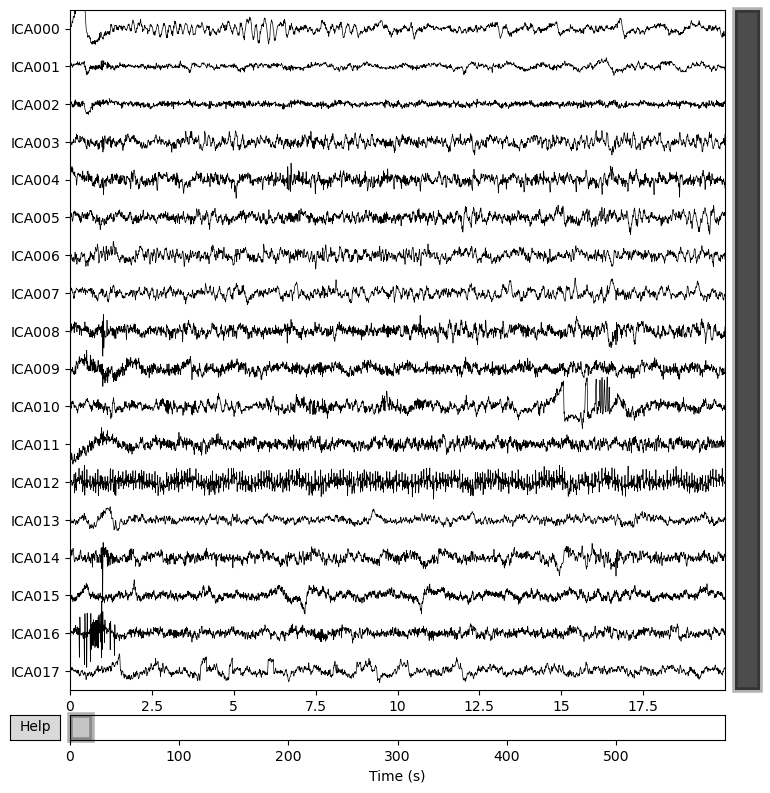

In [25]:
ica.plot_sources(raw_ref);

Visually looking at the plots to identify artifacts that stick out:
- ICA000 looks like a strong frontal gradient, which might correspond to eye-blinks
- ICA005 also lokos like it might correspond with eye-blinks
- ICA010 has a set of bursts around 15 secodns in
- ICA015 has a large and sudden sharp spike early on
- ICA016  has a bit of early spieks and noise

In [36]:
# also instead of doing it visually and pikcing out components that stick out, looks lke MNE has a built-in way to find eye-related components 

eog_indices, scores = ica.find_bads_eog(raw_ref, ch_name='Fp1')
print(eog_indices)

[0]


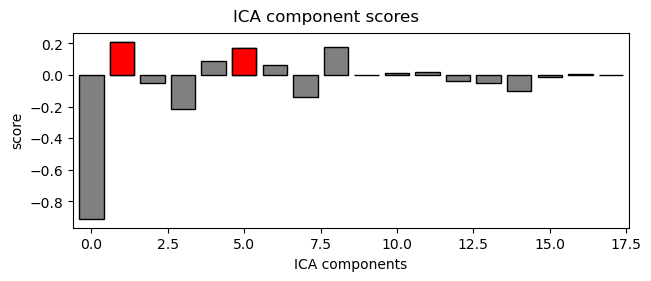

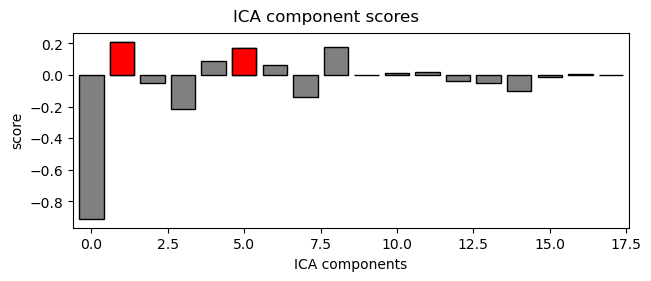

In [37]:
ica.plot_scores(scores)

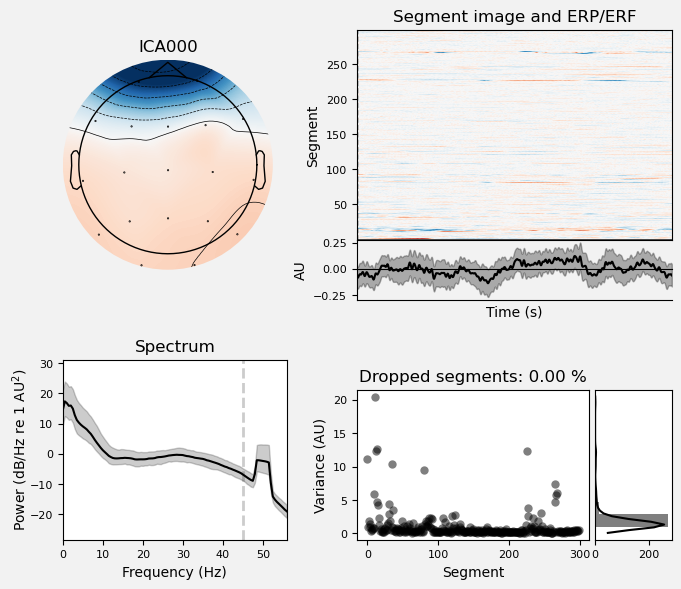

[<Figure size 700x600 with 6 Axes>]

In [38]:
ica.plot_properties(raw_ref, picks=[0])

In [43]:
# remove the componenet

ica.exclude = [0]

raw_clean = raw_ref.copy()
ica.apply(raw_clean)

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

Independent Component Analysis identified a component with a strong frontal scalp topography and dominant low-frequency power which is consistent with ocular artifacts. This component has been removed. 

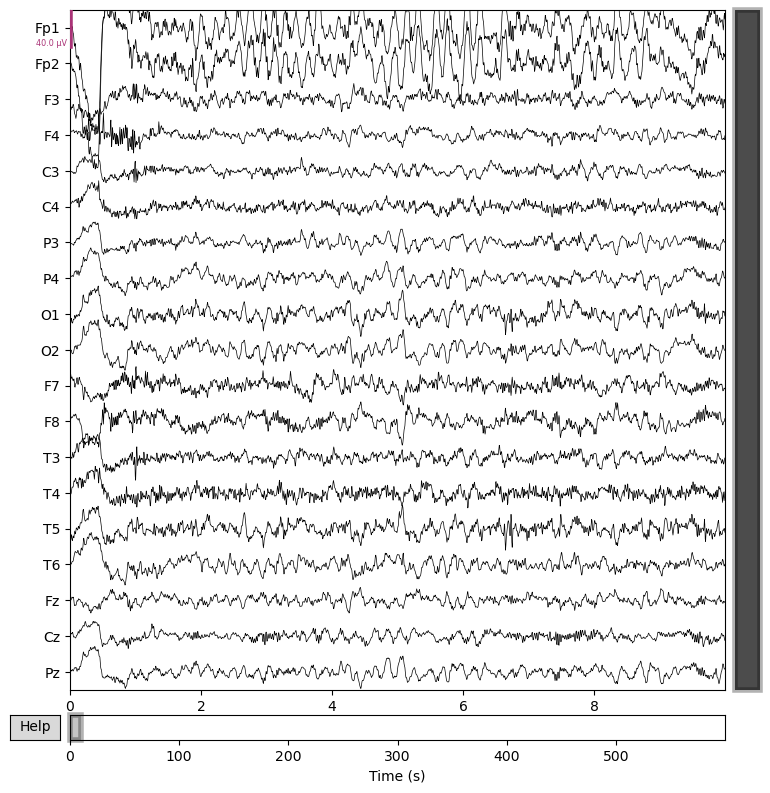

In [44]:
# original 
raw_ref.plot(duration=10);

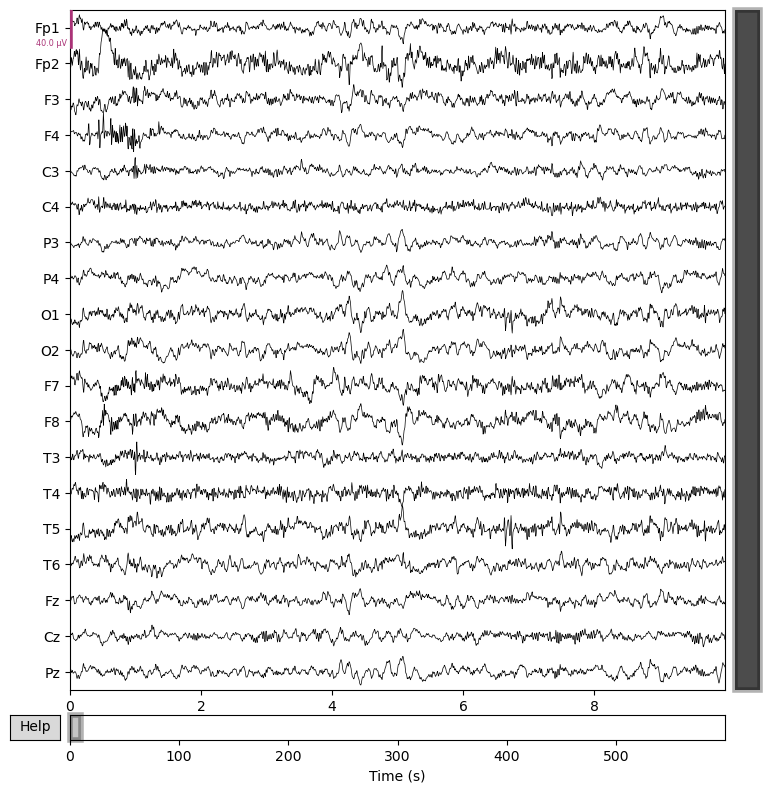

In [45]:
# new after component drop
raw_clean.plot(duration=10);

In the second graph, we see much less ***frontal*** noise